**1) Problem statement**

**This is the prediction of heart disease in a patient based on the dataset availabe ucimlrepo package.

**2) Data Collection**

Package to easily import datasets from the UC Irvine Machine Learning Repository into scripts and notebooks. Current Version: 0.0.

Data Source Reference Link- https://pypi.org/project/ucimlrepo/*

The data consists of 14 column and 303 rows.

**important:** we have already downloaded the dataset into csv format and kept inside notebook/data/heart_disease_uci.csv file.

**2.1 Import Data and Required Packages**

Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [41]:
from IPython.core.display import warnings
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
# Ignore all warnings to keep the output clean
warnings.filterwarnings('ignore')

Import the CSV Data as Pandas DataFrame

In [42]:
heart_df_from_csv = pd.read_csv('data/heart_disease_uci.csv')

Display the first few rows to verify it's loaded correctly

In [43]:
print("DataFrame loaded from 'heart_disease_uci.csv':")
display(heart_df_from_csv.head())

DataFrame loaded from 'heart_disease_uci.csv':


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


 check shape of the dataset

In [44]:
heart_df_from_csv.shape

(303, 14)

Display the data types of each column in the original dataset

In [45]:
print(heart_df_from_csv.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object


Display the first 5 rows of the original dataset to get a glimpse of the data

In [46]:
display(heart_df_from_csv.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


Display a random sample of 5 rows from the original dataset

In [47]:
heart_df_from_csv.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
31,60,1,4,117,230,1,0,160,1,1.4,1,2.0,7.0,2
129,62,0,4,124,209,0,0,163,0,0.0,1,0.0,3.0,0
33,59,1,4,135,234,0,0,161,0,0.5,2,0.0,7.0,0
215,56,1,1,120,193,0,2,162,0,1.9,2,0.0,7.0,0
285,58,1,4,114,318,0,1,140,0,4.4,3,3.0,6.0,4


Display concise summary of the DataFrame, including data types and non-null values

In [48]:
heart_df_from_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


Generate descriptive statistics of the numerical columns in the original dataset

In [49]:
heart_df_from_csv.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


Count the number of missing (NaN) values for each column in the original dataset

In [50]:
heart_df_from_csv.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Fill Nan values with simple imputer method

In [51]:
from sklearn.impute import SimpleImputer

# Create an imputer with a mean strategy to fill missing values
imputer = SimpleImputer(strategy='mean')

# Impute missing values in 'ca' and 'thal' columns using the mean of each column
heart_df_from_csv['ca'] = imputer.fit_transform(heart_df_from_csv[['ca']])
heart_df_from_csv['thal'] = imputer.fit_transform(heart_df_from_csv[['thal']])

# Verify that null values are handled by re-checking the sum of NaN values for these columns
print(heart_df_from_csv[['ca', 'thal']].isna().sum())

ca      0
thal    0
dtype: int64


Verify that all null values across the entire DataFrame are now handled

In [52]:
heart_df_from_csv.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

Check for duplicate rows in the dataset

In [53]:
print(f"Number of duplicate rows in the dataset: {heart_df_from_csv.duplicated().sum()}")

Number of duplicate rows in the dataset: 0


Get the count of unique values for each column in the original dataset

In [54]:
heart_df_from_csv.nunique()

age          41
sex           2
cp            4
trestbps     50
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
num           5
dtype: int64

Attributes Information from https://archive.ics.uci.edu/dataset/45/heart+disease

1 age: age in years

2 sex: sex (1 = male; 0 = female)

3 trestbps: resting blood pressure (in mm Hg on admission to the hospital)

4 cp: chest pain type

    Value 1: typical angina

    Value 2: atypical angina

    Value 3: non-anginal pain

    Value 4: asymptomatic

5 chol: serum cholestoral in mg/dl

6 fbs: (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)

7 restecg: resting electrocardiographic results

    Value 0: normal

    Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

    Value 2: showing probable or definite left ventricular hypertrophy by Estes criteria

8 thalach: maximum heart rate achieved

9 exang: exercise induced angina (1 = yes; 0 = no)

10 oldpeak: ST depression induced by exercise relative to rest

11 slope: the slope of the peak exercise ST segment

    Value 1: upsloping

    Value 2: flat

    Value 3: downsloping

12 ca: number of major vessels (0-3) colored by fluoroscopy

    0: 0 major vessels (0-3) colored by fluoroscopy (no significant blockages detected)

    1: 1 major vessel colored by fluoroscopy

    2: 2 major vessels colored by fluoroscopy

    3: 3 major vessels colored by fluoroscopy (indicates more severe coronary artery disease)

13 thal: 3 = normal; 6 = fixed defect; 7 = reversable defect

14 num: diagnosis of heart disease (angiographic disease status)

    Value 0: < 50% diameter narrowing

    Value 1: > 50% diameter narrowing
    0: No heart disease (absence of heart disease)

    1: Heart disease stage 1 (mild presence)

    2: Heart disease stage 2 (moderate presence)

    3: Heart disease stage 3 (significant presence)
    
    4: Heart disease stage 4 (severe presence)

In [55]:
import numpy as np

# Define the features for which to show distinct value meanings
features_to_explain = [
    'sex','cp', 'fbs', 'restecg',
    'exang', 'ca', 'thal',
    'num'
]

print("Meaning of Distinct Values for Selected Features:")
print("=" * 50)

for feature in features_to_explain:
    print(f"\nFeature: {feature}")
    distinct_values = heart_df_from_csv[feature].unique()
    # Sort distinct values for better readability, if numeric
    if np.issubdtype(distinct_values.dtype, np.number):
        distinct_values.sort()
    print(f"  Distinct values observed: {distinct_values}")

    print("  Interpretations:")
    if feature == 'cp':
        print("    1: Typical Angina (chest pain due to reduced blood flow to the heart)")
        print("    2: Atypical Angina (chest pain not clearly related to heart problems)")
        print("    3: Non-Anginal Pain (chest pain unrelated to heart problems, e.g., muscle strain)")
        print("    4: Asymptomatic (no chest pain symptoms, though blockages may be present)")
    elif feature == 'fbs':
        print("    0: Fasting Blood Sugar <= 120 mg/dl (Normal blood sugar level)")
        print("    1: Fasting Blood Sugar > 120 mg/dl (High blood sugar - typically indicative of diabetes or pre-diabetes)")
    elif feature == 'restecg':
        print("    0: Normal (nothing abnormal detected)")
        print("    1: Having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV - indicates potential heart problems)")
        print("    2: Showing probable or definite left ventricular hypertrophy by Estes' criteria (enlargement of the left ventricle, a sign of heart disease)")
    elif feature == 'exang':
        print("    0: No (No exercise-induced angina)")
        print("    1: Yes (Angina induced by exercise)")
    elif feature == 'ca':
        print("    0: 0 major vessels (0-3) colored by fluoroscopy (no significant blockages detected)")
        print("    1: 1 major vessel colored by fluoroscopy")
        print("    2: 2 major vessels colored by fluoroscopy")
        print("    3: 3 major vessels colored by fluoroscopy (indicates more severe coronary artery disease)")
        # Check for fractional values due to imputation
        fractional_values = [val for val in distinct_values if val != int(val)]
        if fractional_values:
             print(f"    Note: Fractional values like {fractional_values} indicate imputed missing data, originally integers 0-3.")
    elif feature == 'thal':
        print("    3: Normal (blood flow during stress test is normal)")
        print("    6: Fixed defect (areas of the heart that consistently show reduced blood flow, even at rest)")
        print("    7: Reversible defect (areas of the heart that show reduced blood flow during stress but normal flow at rest - indicates ischemia)")
        # Check for fractional values due to imputation
        fractional_values = [val for val in distinct_values if val != int(val)]
        if fractional_values:
            print(f"    Note: Fractional values like {fractional_values} indicate imputed missing data, originally integers 3, 6, 7.")
    elif feature == 'num':
        print("    0: No heart disease (absence of heart disease)")
        print("    1: Heart disease stage 1 (mild presence)")
        print("    2: Heart disease stage 2 (moderate presence)")
        print("    3: Heart disease stage 3 (significant presence)")
        print("    4: Heart disease stage 4 (severe presence)")
    else:
        print("  No specific interpretations for distinct values readily available in metadata for this feature.")

    print("=" * 50)

Meaning of Distinct Values for Selected Features:

Feature: sex
  Distinct values observed: [0 1]
  Interpretations:
  No specific interpretations for distinct values readily available in metadata for this feature.

Feature: cp
  Distinct values observed: [1 2 3 4]
  Interpretations:
    1: Typical Angina (chest pain due to reduced blood flow to the heart)
    2: Atypical Angina (chest pain not clearly related to heart problems)
    3: Non-Anginal Pain (chest pain unrelated to heart problems, e.g., muscle strain)
    4: Asymptomatic (no chest pain symptoms, though blockages may be present)

Feature: fbs
  Distinct values observed: [0 1]
  Interpretations:
    0: Fasting Blood Sugar <= 120 mg/dl (Normal blood sugar level)
    1: Fasting Blood Sugar > 120 mg/dl (High blood sugar - typically indicative of diabetes or pre-diabetes)

Feature: restecg
  Distinct values observed: [0 1 2]
  Interpretations:
    0: Normal (nothing abnormal detected)
    1: Having ST-T wave abnormality (T wave i

In [56]:
#Check dataset after rename
print("DataFrame after renaming columns:")
display(heart_df_from_csv.head())

DataFrame after renaming columns:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [57]:
# code to check if we have nay 0 values in the listed features ,as 0 value doesn't make sense for a peron.
columns_to_check = ['trestbps', 'chol', 'thalach', 'oldpeak']

for col in columns_to_check:
    zero_count = (heart_df_from_csv[col] == 0).sum()
    print(f"Number of 0 values in '{col}': {zero_count}")

Number of 0 values in 'trestbps': 0
Number of 0 values in 'chol': 0
Number of 0 values in 'thalach': 0
Number of 0 values in 'oldpeak': 99


In [58]:
from sklearn.impute import KNNImputer

# Make a copy to preserve the original DataFrame if needed for other comparisons
df_knn_imputed = heart_df_from_csv.copy()

# Replace 0 values in 'oldpeak' with NaN to be imputed by KNNImputer
df_knn_imputed['oldpeak'] = df_knn_imputed['oldpeak'].replace(0, np.nan)

# Initialize KNNImputer
# n_neighbors specifies the number of neighbors to consider for imputation
knn_imputer = KNNImputer(n_neighbors=5)

# Apply KNN imputation to the 'oldpeak' column
# Note: KNNImputer expects a 2D array, so we pass df[['column_name']]
df_knn_imputed['oldpeak'] = knn_imputer.fit_transform(df_knn_imputed[['oldpeak']])

# Verify that 0 values are handled by re-checking the sum of 0 values for this column
zero_oldpeak_count_after_knn_fix = (df_knn_imputed['oldpeak'] == 0).sum()
print(f"Number of 0 values in 'oldpeak' after KNN imputation: {zero_oldpeak_count_after_knn_fix}")

# Display descriptive statistics to see the effect of KNN imputation
print("\nDescriptive statistics for 'oldpeak' after KNN imputation:")
display(df_knn_imputed['oldpeak'].describe())

Number of 0 values in 'oldpeak' after KNN imputation: 0

Descriptive statistics for 'oldpeak' after KNN imputation:


count    303.000000
mean       1.544118
std        0.906567
min        0.100000
25%        1.000000
50%        1.544118
75%        1.600000
max        6.200000
Name: oldpeak, dtype: float64

In [59]:
# Verify that there are no 0 values in 'oldpeak' after KNN imputation
zero_count_final = (df_knn_imputed['oldpeak'] == 0).sum()
print(f"Final count of 0 values in 'oldpeak' after KNN imputation: {zero_count_final}")

if zero_count_final == 0:
    print("Successfully confirmed: No zero values found in 'oldpeak' after KNN imputation.")
else:
    print(f"Warning: {zero_count_final} zero values still present in 'oldpeak'.")

Final count of 0 values in 'oldpeak' after KNN imputation: 0
Successfully confirmed: No zero values found in 'oldpeak' after KNN imputation.


In [60]:
# Assign the KNN imputed 'oldpeak' values back to the original DataFrame
heart_df_from_csv['oldpeak'] = df_knn_imputed['oldpeak']

# Display the first few rows and check the info to confirm the update
print("DataFrame 'heart_df_from_csv' after updating 'oldpeak':")
display(heart_df_from_csv.head())
heart_df_from_csv.info()

DataFrame 'heart_df_from_csv' after updating 'oldpeak':


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [61]:
# Final verification: Check for 0 values in 'oldpeak' in the main DataFrame
final_zero_count_original_df = (heart_df_from_csv['oldpeak'] == 0).sum()

print(f"Final count of 0 values in 'heart_df_from_csv['oldpeak']': {final_zero_count_original_df}")

if final_zero_count_original_df == 0:
    print("Confirmed: 'oldpeak' in the main DataFrame has no zero values.")
else:
    print(f"Alert: {final_zero_count_original_df} zero values found in 'oldpeak' in the main DataFrame. Further investigation may be needed.")

Final count of 0 values in 'heart_df_from_csv['oldpeak']': 0
Confirmed: 'oldpeak' in the main DataFrame has no zero values.


In [62]:
# Calculate the correlation matrix for all features in the original DataFrame
# This helps in understanding the linear relationships between variables.
heart_df_from_csv.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
age,1.000000,-0.097542,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.047337,0.161770,0.359489,0.127368,0.222853
sex,-0.097542,1.000000,0.010084,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.078875,0.037533,0.092891,0.379300,0.224469
cp,0.104139,0.010084,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.143441,0.152050,0.232332,0.264895,0.407075
trestbps,0.284946,-0.064456,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.163675,0.117382,0.098707,0.133534,0.157754
chol,0.208950,-0.199915,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.016761,-0.004062,0.118525,0.014190,0.070909
fbs,0.118530,0.047862,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,-0.035437,0.059894,0.143967,0.070658,0.059186
restecg,0.148868,0.021647,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.100715,0.133946,0.127487,0.024449,0.183696
thalach,-0.393806,-0.048663,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.134937,-0.385601,-0.263408,-0.278530,-0.415040
exang,0.091661,0.146201,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.208911,0.257748,0.144722,0.328291,0.397057
oldpeak,0.047337,0.078875,0.143441,0.163675,0.016761,-0.035437,0.100715,-0.134937,0.208911,1.000000,0.341863,0.230639,0.176650,0.407844


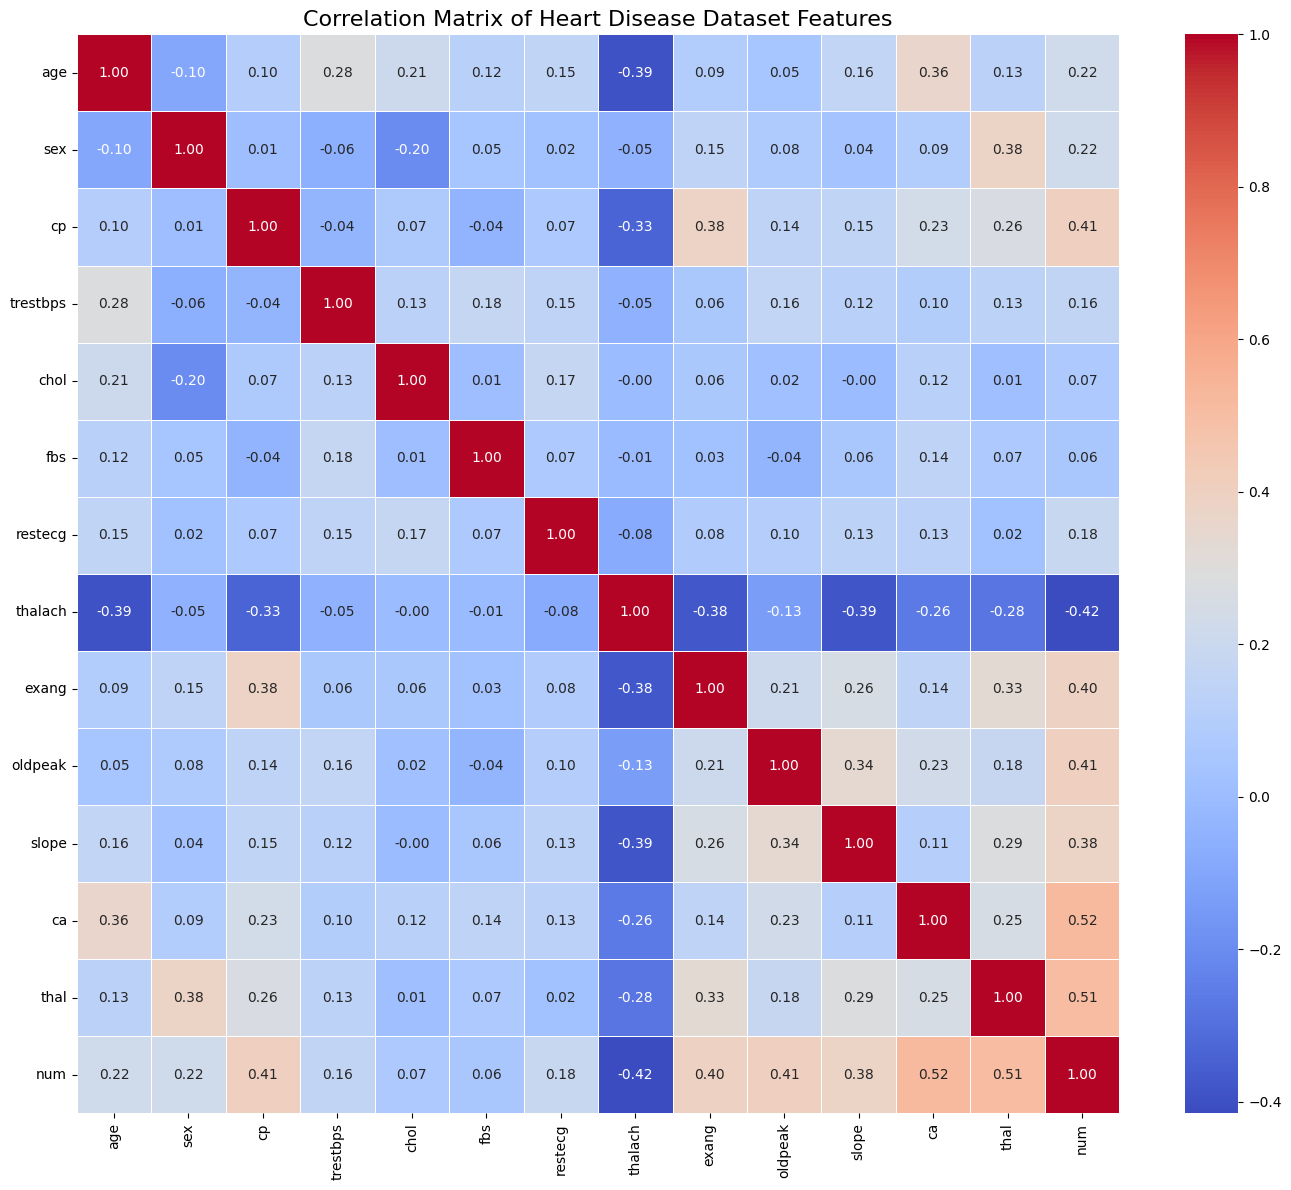

In [63]:
correlation_matrix = heart_df_from_csv.corr()

# Visualize the correlation matrix using a heatmap from the seaborn library.
# A heatmap is an effective way to display the magnitude of correlations between variables
# using a color gradient, making patterns and strong relationships easily identifiable.
plt.figure(figsize=(14, 12)) # Set a larger figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Heart Disease Dataset Features', fontsize=16)
plt.xticks(rotation=90) # Rotate x-axis labels for better visibility
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

**Visualizing Feature Distributions with Histograms**

Histograms are fundamental tools for understanding the distribution of numerical data. They help us:

Identify the shape of the distribution: Is it symmetric, skewed (left or right), bimodal, or uniform?

Locate the central tendency: Where is the data concentrated?

Assess the spread of the data: How much variability is there?

Detect outliers or anomalies: Are there values far removed from the bulk of the data?

Understand the frequency of different values: How often do certain values or ranges occur?

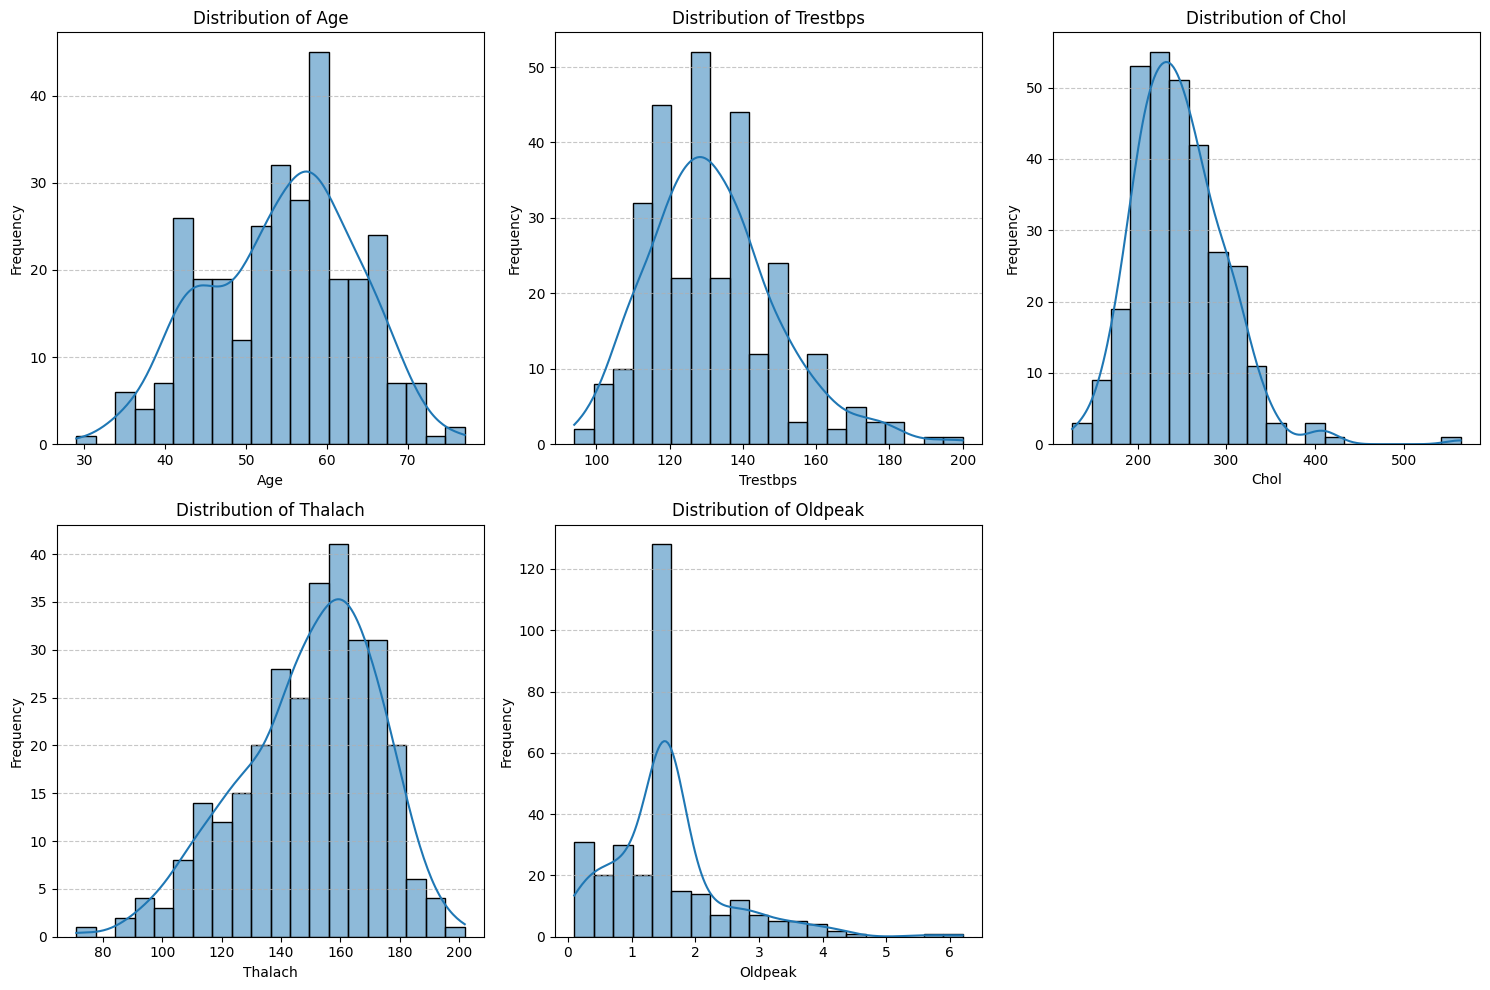

In [64]:
# Select some key numerical features for histogram visualization
features_for_histograms = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

# Create histograms for selected features
plt.figure(figsize=(15, 10)) # Adjust figure size for multiple plots

for i, feature in enumerate(features_for_histograms, 1):
    plt.subplot(2, 3, i) # Arrange plots in a 2x3 grid
    sns.histplot(heart_df_from_csv[feature], kde=True, bins=20) # Use kde for density curve
    plt.title(f'Distribution of {feature.replace("_", " ").title()}')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping plots
plt.show()

Analysis as per Histogram

Age: The distribution is somewhat normal, peaking around the mid-50s.

Resting Blood Pressure(trestbps): Also appears somewhat normal, concentrating between 120-140 mmHg.

Serum Cholestoral (chol): Shows a right-skewed distribution, with most values lower and a tail extending to higher levels.

Max Heart Rate (thalach): This feature is left-skewed, indicating a higher concentration of individuals with elevated maximum heart rates.

ST Depression (oldpeak): Heavily right-skewed with a prominent peak at lower values, consistent with the previous imputation of zero values.



**Visualizing Class Balance of the Target Variable**

Understanding the class balance of the target variable (num in this case) is crucial for several reasons:

**Representativeness:** It tells us how well each class is represented in the dataset. A heavily imbalanced dataset (where one class has significantly fewer instances than others) can lead to models that perform well on the majority class but poorly on the minority class.

**Model Performance:** Many machine learning algorithms assume a balanced class distribution. If the dataset is imbalanced, the model might become biased towards the majority class, leading to high accuracy but poor recall or precision for the minority class, which is often the class of interest (e.g., detecting rare diseases).

**Evaluation Metrics:** For imbalanced datasets, accuracy alone can be misleading. Metrics like precision, recall, F1-score, and AUC-ROC become more relevant for evaluating model performance.

**Preprocessing Strategies:** Identifying class imbalance early helps in deciding whether to apply techniques like oversampling (e.g., SMOTE), undersampling, or using algorithms robust to imbalance during model training.

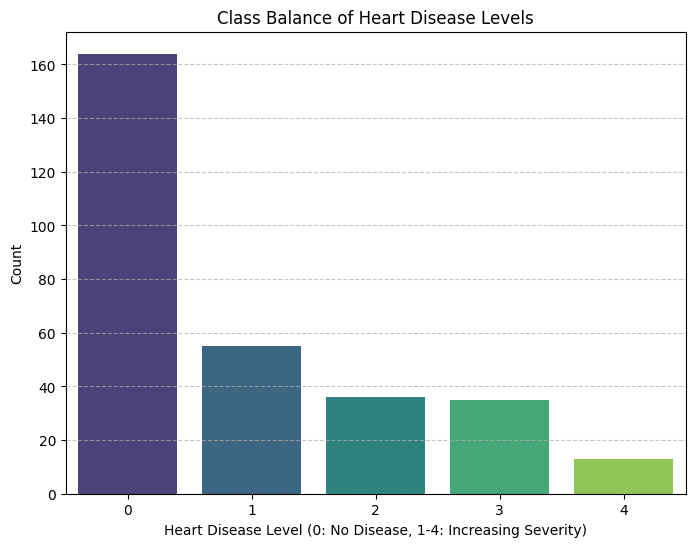

Counts of each Heart Disease Level:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [65]:
# Visualize the class balance of the target variable 'num'
plt.figure(figsize=(8, 6))
sns.countplot(x='num', data=heart_df_from_csv, palette='viridis')
plt.title('Class Balance of Heart Disease Levels')
plt.xlabel('Heart Disease Level (0: No Disease, 1-4: Increasing Severity)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display the actual counts for better understanding
print("Counts of each Heart Disease Level:")
print(heart_df_from_csv['num'].value_counts())

Based on the bar plot and the counts, it's clear that the target variable num exhibits a significant class imbalance. The majority of the instances fall into class 0 (No heart disease), with 164 observations. As the severity level increases, the number of instances decreases substantially, with class 4 (severe presence) having the fewest instances, only 13.

This imbalance is a critical finding for data analysis and future model building. It implies that a machine learning model trained directly on this dataset might become biased towards predicting the majority class (no heart disease) and struggle to accurately identify the less frequent, but often more critical, severe heart disease cases. This could lead to a model with high overall accuracy but poor performance (e.g., low recall) for the minority classes. Therefore, techniques such as oversampling, undersampling, or using specific algorithms designed for imbalanced data will likely be necessary during model development to ensure fair and effective predictions across all heart disease levels.

In [66]:
# Save the preprocessed dataset to CSV
output_path = './data/preprocessed.csv'
heart_df_from_csv.to_csv(output_path, index=False)
print(f"Preprocessed dataset saved successfully to: {output_path}")
print(f"Dataset shape: {heart_df_from_csv.shape}")
print(f"Dataset columns: {list(heart_df_from_csv.columns)}")

Preprocessed dataset saved successfully to: ./data/preprocessed.csv
Dataset shape: (303, 14)
Dataset columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


Saving the preprocessed data as preprocessed.csv s that we can utilise in MODEL_TRAINING.ipynb file for model training purpose.